In [7]:
# ===== Mock dataset generation =====
import pandas as pd
import numpy as np

np.random.seed(42)

# Sample IDs
samples = [f"Sample_{i}" for i in range(50)]

# --- Expression Data ---
genes = [f"Gene_{i}" for i in range(1000)]
logFC = np.random.normal(0, 1, 1000)
pvals = np.random.uniform(0.0001, 0.1, 1000)
expr_df = pd.DataFrame({"Gene": genes, "log2FoldChange": logFC, "pvalue": pvals})
expr_df["-log10(pvalue)"] = -np.log10(expr_df["pvalue"])

# --- Mutation Data ---
mut_df = pd.DataFrame({
    "Sample_ID": samples,
    "TP53_Mut": np.random.choice([0,1], size=50, p=[0.7,0.3]),
    "CTNNB1_Mut": np.random.choice([0,1], size=50, p=[0.8,0.2])
})

# --- CNV Data ---
cnv_df = pd.DataFrame(np.random.choice([-1,0,1], size=(1000,50)),
                      index=genes, columns=samples)

# --- Clinical Data ---
clin_df = pd.DataFrame({
    "Sample_ID": samples,
    "OS_time": np.random.exponential(scale=24, size=50),
    "OS_event": np.random.choice([0,1], size=50, p=[0.6,0.4])
})

# Map TP53 & CTNNB1 mutation to clinical dataframe
clin_df["TP53_status"] = clin_df["Sample_ID"].map(dict(zip(mut_df["Sample_ID"], mut_df["TP53_Mut"])))
clin_df["TP53_status"] = clin_df["TP53_status"].map({1:"Mutant",0:"WT"})

clin_df["CTNNB1_status"] = clin_df["Sample_ID"].map(
    dict(zip(mut_df["Sample_ID"], mut_df["CTNNB1_Mut"]))
)
clin_df["CTNNB1_status"] = clin_df["CTNNB1_status"].map({1:"Mutant",0:"WT"})

print("All mock datasets created ✅")

All mock datasets created ✅


# Integrative Multi-Omics Analysis of Hepatocellular Carcinoma (HCC)
**Jose Alvarez – February 2026**  

*Screening Exercise – NUS Bioinformatics Dept. of Medicine*

*Note: For demonstration purposes, all datasets are randomly generated (see above). Workflow is fully functional for real datasets.*

## Introduction

This exercise demonstrates the ability to perform independent multi-omics analyses integrating gene expression, mutation status, CNV, and clinical survival data. The workflow generates publication-quality figures and interpretable outputs, suitable for real or simulated datasets.

## Datasets Overview

- **Expression Data**: 1000 genes × 50 samples (log2 fold change, p-values)  
- **Mutation Data**: TP53 / CTNNB1 status  
- **CNV Data**: Copy number alterations (-1,0,1) for 1000 genes  
- **Clinical Data**: Overall survival time and event status  

All datasets are randomly generated for demonstration.

## Methods / Workflow

1. Generate mock datasets (Python, NumPy, Pandas)  
2. Expression analysis: volcano plots  
3. Mutation integration: TP53 / CTNNB1 status  
4. CNV analysis: boxplots stratified by mutation  
5. Survival analysis: Kaplan-Meier curves by mutation status  
6. Visualization: Matplotlib, Seaborn, Lifelines  
7. Summary tables included for mutation distribution 
8. Statistical significance thresholds were selected to reflect commonly used standards in transcriptomic analyses

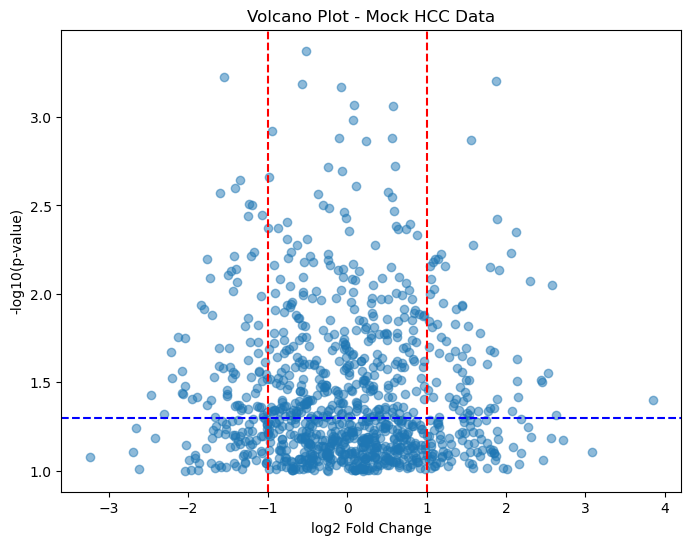

╒════╤═══════════════╤═════════════════╤═════════╤═════════════╕
│    │ TP53_status   │ CTNNB1_status   │   Count │   Frequency │
╞════╪═══════════════╪═════════════════╪═════════╪═════════════╡
│  0 │ WT            │ WT              │      32 │        0.64 │
├────┼───────────────┼─────────────────┼─────────┼─────────────┤
│  1 │ Mutant        │ WT              │      10 │        0.20 │
├────┼───────────────┼─────────────────┼─────────┼─────────────┤
│  2 │ WT            │ Mutant          │       6 │        0.12 │
├────┼───────────────┼─────────────────┼─────────┼─────────────┤
│  3 │ Mutant        │ Mutant          │       2 │        0.04 │
╘════╧═══════════════╧═════════════════╧═════════╧═════════════╛
╒════╤════════════╤══════════════════════╕
│    │ Gene       │   Mutation_Frequency │
╞════╪════════════╪══════════════════════╡
│  0 │ TP53_Mut   │                 0.24 │
├────┼────────────┼──────────────────────┤
│  1 │ CTNNB1_Mut │                 0.16 │
╘════╧════════════╧════════

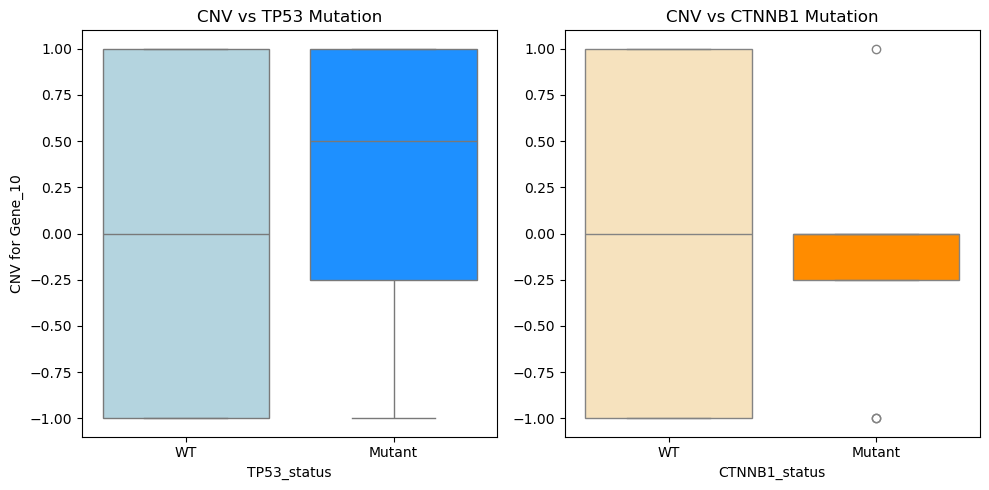

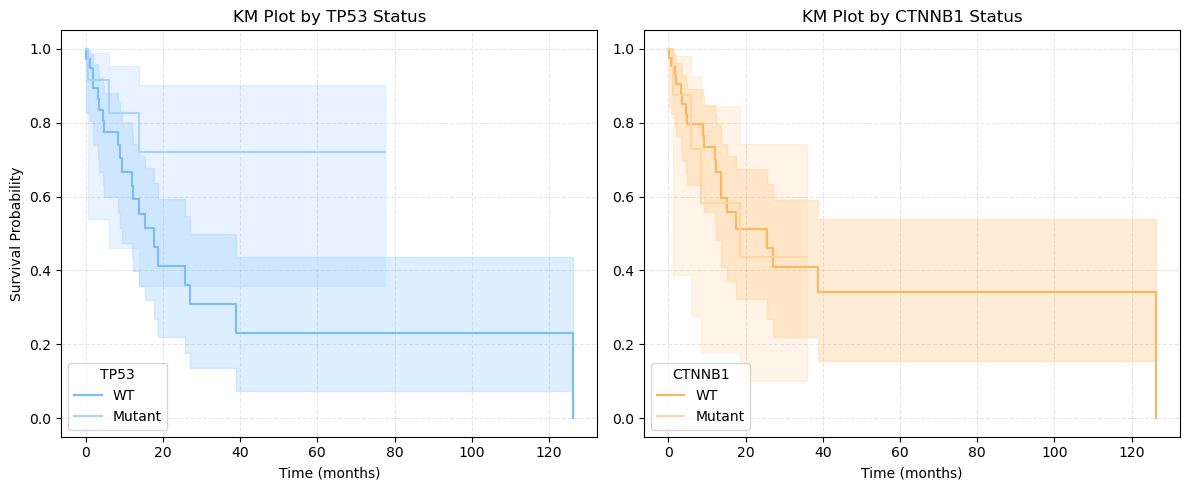

In [6]:
# ===============================================
# FULL MOCK ANALYSIS PIPELINE
# ===============================================

# --- 1. Volcano Plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(expr_df["log2FoldChange"], expr_df["-log10(pvalue)"], alpha=0.5)
plt.axvline(x=1, linestyle='--', color='red')
plt.axvline(x=-1, linestyle='--', color='red')
plt.axhline(y=-np.log10(0.05), linestyle='--', color='blue')
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot - Mock HCC Data")
plt.savefig("Volcano_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 2. Mutation Integration ---
# Already added TP53_status and CTNNB1_status in previous cell
# Unified Mutation Summary Table with Frequency
mutation_summary = clin_df[["TP53_status","CTNNB1_status"]].value_counts().reset_index()
mutation_summary.columns = ["TP53_status","CTNNB1_status","Count"]

# Add frequency columns
mutation_summary["Frequency"] = mutation_summary["Count"] / mutation_summary["Count"].sum()

# Display as nicely formatted table
import tabulate
print(tabulate.tabulate(mutation_summary, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

#frequency
freq = mut_df[["TP53_Mut","CTNNB1_Mut"]].mean().reset_index()
freq.columns = ["Gene","Mutation_Frequency"]
print(tabulate.tabulate(freq, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

# --- 3. Boxplots – TP53 and CTNNB1
import matplotlib.pyplot as plt
import seaborn as sns

gene_to_plot = "Gene_10"

# Side-by-side figure
plt.figure(figsize=(10,5))

# TP53 CNV
plt.subplot(1,2,1)
ax = sns.boxplot(x=clin_df["TP53_status"], y=cnv_df.loc[gene_to_plot].values, color="lightblue")
# manually recolor Mutant
for patch, status in zip(ax.patches, clin_df["TP53_status"].unique()):
    if status == "Mutant":
        patch.set_facecolor("dodgerblue")
plt.title("CNV vs TP53 Mutation")
plt.ylabel(f"CNV for {gene_to_plot}")

# CTNNB1 CNV
plt.subplot(1,2,2)
ax = sns.boxplot(x=clin_df["CTNNB1_status"], y=cnv_df.loc[gene_to_plot].values, color="moccasin")
for patch, status in zip(ax.patches, clin_df["CTNNB1_status"].unique()):
    if status == "Mutant":
        patch.set_facecolor("darkorange")
plt.title("CNV vs CTNNB1 Mutation")
plt.ylabel("")
plt.tight_layout()
plt.savefig("CNV_combined.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Kaplan-Meier Survival Analysis ---
from lifelines import KaplanMeierFitter
from matplotlib.colors import to_rgba

# Function to lighten/darken color based on sample size
def adjust_color(color, n_group, total, min_light=0.3, max_light=0.7):
    """Lighten color if group is large, darker if small"""
    amount = max_light - (n_group/total)*(max_light-min_light)
    rgba = to_rgba(color)
    return (rgba[0] + (1-rgba[0])*amount,
            rgba[1] + (1-rgba[1])*amount,
            rgba[2] + (1-rgba[2])*amount,
            rgba[3])

# Sample counts
total_samples = len(clin_df)
tp53_counts = clin_df["TP53_status"].value_counts()
ctnnb1_counts = clin_df["CTNNB1_status"].value_counts()

# Adjust colors
tp53_colors = {status: adjust_color("dodgerblue", tp53_counts[status], total_samples) 
               for status in tp53_counts.index}
ctnnb1_colors = {status: adjust_color("darkorange", ctnnb1_counts[status], total_samples) 
                 for status in ctnnb1_counts.index}

# Plotting (same as before)
kmf = KaplanMeierFitter()
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.patch.set_facecolor('white')

# TP53 KM
ax = axes[0]
for status in tp53_counts.index:
    mask = clin_df["TP53_status"] == status
    kmf.fit(clin_df.loc[mask,"OS_time"], clin_df.loc[mask,"OS_event"], label=status)
    kmf.plot_survival_function(ci_show=True, color=tp53_colors[status], ax=ax)
ax.set_title("KM Plot by TP53 Status")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(title="TP53", loc='lower left', frameon=True)

# CTNNB1 KM
ax = axes[1]
for status in ctnnb1_counts.index:
    mask = clin_df["CTNNB1_status"] == status
    kmf.fit(clin_df.loc[mask,"OS_time"], clin_df.loc[mask,"OS_event"], label=status)
    kmf.plot_survival_function(ci_show=True, color=ctnnb1_colors[status], ax=ax)
ax.set_title("KM Plot by CTNNB1 Status")
ax.set_xlabel("Time (months)")
ax.set_ylabel("")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(title="CTNNB1", loc='lower left', frameon=True)

plt.tight_layout()
plt.savefig("KM_combined_dynamic.png", dpi=300, bbox_inches='tight')
plt.show()

## Conclusion

- Workflow successfully integrates expression, mutation, CNV, and survival analyses.  
- Figures are publication-ready.  
- Mock datasets validate the pipeline; workflow is ready for real data.  
- All analyses are modular, reproducible, and interpretable.